In [50]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal


# ============================================================
# Paper-aligned defaults (only what is explicitly stated)
# ============================================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

LR_ACTOR = 1e-4       # paper Table 1
LR_CRITIC = 1e-3      # paper Table 1
GAMMA = 0.3           # paper Table 1
BATCH_SIZE = 128      # paper Table 1
BP = 0.0020           # paper Table 1
MU = 1.0              # paper Eq.4 text
WINDOW = 60           # past 60 observations in state
HIDDEN_SIZES = [64, 32]   # paper Section 4.3
LEAKY_RELU_SLOPE = 0.01


# ============================================================
# 1) Two-layer LSTM backbone
#    Paper says:
#      - LSTM for actor and critic
#      - two-layer LSTM
#      - 64 and 32 units
#      - Leaky-ReLU activation
# ============================================================
class StackedLSTMBackbone(nn.Module):
    def __init__(self, input_size, hidden_sizes=(64, 32)):
        super().__init__()
        self.lstm1 = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_sizes[0],
            num_layers=1,
            batch_first=True,
        )
        self.lstm2 = nn.LSTM(
            input_size=hidden_sizes[0],
            hidden_size=hidden_sizes[1],
            num_layers=1,
            batch_first=True,
        )
        self.act = nn.LeakyReLU(LEAKY_RELU_SLOPE)

    def forward(self, x):
        # x: (batch, seq_len, n_features)
        out1, _ = self.lstm1(x)
        out1 = self.act(out1)

        out2, _ = self.lstm2(out1)
        out2 = self.act(out2)

        # IMPLEMENTATION ASSUMPTION:
        # paper does not specify pooling/readout method from LSTM.
        # Standard choice: use last time-step hidden representation.
        return out2[:, -1, :]   # (batch, 32)


# ============================================================
# 2) Actor: continuous action in [-1, 1]
#    Paper states A2C uses continuous action space [−1,1],
#    but does not specify the exact policy distribution.
# ============================================================
class ActorContinuous(nn.Module):
    def __init__(self, input_size, hidden_sizes=(64, 32)):
        super().__init__()
        self.backbone = StackedLSTMBackbone(input_size, hidden_sizes)
        self.mu_head = nn.Linear(hidden_sizes[-1], 1)

        # IMPLEMENTATION ASSUMPTION:
        # paper does not specify how to parameterize continuous action policy.
        # We use a Gaussian policy with a trainable global log_std.
        self.log_std = nn.Parameter(torch.tensor(-0.5, dtype=torch.float32))

    def forward(self, x):
        h = self.backbone(x)
        mu = torch.tanh(self.mu_head(h))   # action mean constrained to [-1,1]
        std = torch.exp(self.log_std).clamp(min=1e-4, max=2.0)
        return mu, std

    def sample_action(self, x):
        mu, std = self.forward(x)
        dist = Normal(mu, std)

        z = dist.rsample()
        action = torch.tanh(z)

        # tanh squash correction
        log_prob = dist.log_prob(z) - torch.log(1 - action.pow(2) + 1e-6)
        log_prob = log_prob.sum(dim=-1)

        entropy = dist.entropy().sum(dim=-1)
        return action, log_prob, entropy

    def deterministic_action(self, x):
        mu, _ = self.forward(x)
        return torch.tanh(mu)


# ============================================================
# 3) Critic: state value V(s)
# ============================================================
class CriticValue(nn.Module):
    def __init__(self, input_size, hidden_sizes=(64, 32)):
        super().__init__()
        self.backbone = StackedLSTMBackbone(input_size, hidden_sizes)
        self.value_head = nn.Linear(hidden_sizes[-1], 1)

    def forward(self, x):
        h = self.backbone(x)
        v = self.value_head(h)
        return v.squeeze(-1)


# ============================================================
# 4) Paper-style trading environment
#
#    Expected inputs:
#      X: shape (n_samples, 60, n_features)
#      aligned_df: DataFrame aligned with X, containing at least:
#        date, close, ret_1d, ewm_vol_60
#
#    Reward logic follows the paper's Eq.(4), with timing written as:
#      choose A_t from state at time t
#      receive reward on t -> t+1
#
#    sigma_target is left as an input argument because the paper
#    includes sigma_tgt in Eq.(4) but does not fix one universal value.
# ============================================================
class PaperTradingEnv:
    def __init__(
        self,
        X,
        aligned_df,
        sigma_target,
        bp=BP,
        mu=MU,
    ):
        self.X = np.asarray(X, dtype=np.float32)
        self.df = aligned_df.reset_index(drop=True).copy()
        self.sigma_target = sigma_target
        self.bp = bp
        self.mu = mu

        required_cols = ["date", "close", "ret_1d", "ewm_vol_60"]
        missing = [c for c in required_cols if c not in self.df.columns]
        if missing:
            raise ValueError(f"aligned_df missing required columns: {missing}")

        if len(self.X) != len(self.df):
            raise ValueError("X and aligned_df must have the same number of samples.")

        self.n = len(self.df)
        self.reset()

    def reset(self):
        self.t = 0
        self.prev_action = 0.0
        return self.X[self.t]

    def step(self, action):
        action = float(np.clip(action, -1.0, 1.0))

        if self.t >= self.n - 1:
            return self.X[self.t], 0.0, True, {}

        row_t = self.df.iloc[self.t]
        row_tp1 = self.df.iloc[self.t + 1]

        sigma_t = row_t["ewm_vol_60"]
        sigma_tm1 = self.df.iloc[self.t - 1]["ewm_vol_60"] if self.t - 1 >= 0 else np.nan
        price_t = row_t["close"]
        r_tp1 = row_tp1["ret_1d"]

        if pd.isna(sigma_t) or sigma_t == 0 or pd.isna(price_t) or pd.isna(r_tp1):
            reward = np.nan
        else:
            scaled_pos_t = self.sigma_target / sigma_t * action

            if self.t == 0 or pd.isna(sigma_tm1) or sigma_tm1 == 0:
                scaled_pos_tm1 = 0.0
            else:
                scaled_pos_tm1 = self.sigma_target / sigma_tm1 * self.prev_action

            gross = self.mu * scaled_pos_t * r_tp1
            cost = self.mu * self.bp * price_t * abs(scaled_pos_t - scaled_pos_tm1)
            reward = gross - cost

        self.prev_action = action
        self.t += 1
        done = self.t >= self.n - 1

        next_state = self.X[self.t]
        info = {
            "date": row_tp1["date"],
            "reward": reward,
        }
        return next_state, float(0.0 if pd.isna(reward) else reward), done, info


# ============================================================
# 5) Collect synchronous rollouts across environments
# ============================================================
def collect_rollout(envs, actor, critic, rollout_steps, device=DEVICE):
    states = []
    actions = []
    rewards = []
    dones = []
    values = []

    if not hasattr(collect_rollout, "_current_states") or len(collect_rollout._current_states) != len(envs):
        collect_rollout._current_states = [env.reset() for env in envs]

    current_states = collect_rollout._current_states

    for _ in range(rollout_steps):
        state_batch = torch.tensor(np.stack(current_states), dtype=torch.float32, device=device)

        with torch.no_grad():
            action_batch, _, _ = actor.sample_action(state_batch)
            value_batch = critic(state_batch)

        next_states = []
        reward_batch = []
        done_batch = []

        for i, env in enumerate(envs):
            a = action_batch[i].item()
            ns, r, d, _ = env.step(a)

            if d:
                ns = env.reset()

            next_states.append(ns)
            reward_batch.append(r)
            done_batch.append(float(d))

        states.append(state_batch)
        actions.append(action_batch.squeeze(-1))
        rewards.append(torch.tensor(reward_batch, dtype=torch.float32, device=device))
        dones.append(torch.tensor(done_batch, dtype=torch.float32, device=device))
        values.append(value_batch)

        current_states = next_states

    collect_rollout._current_states = current_states

    last_state_batch = torch.tensor(np.stack(current_states), dtype=torch.float32, device=device)
    with torch.no_grad():
        last_values = critic(last_state_batch)

    batch = {
        "states": torch.stack(states),       # (T, N, 60, F)
        "actions": torch.stack(actions),     # (T, N)
        "rewards": torch.stack(rewards),     # (T, N)
        "dones": torch.stack(dones),         # (T, N)
        "values": torch.stack(values),       # (T, N)
        "last_values": last_values,          # (N,)
    }
    return batch


# ============================================================
# 6) Returns / advantages
# ============================================================
def compute_returns_and_advantages(rewards, dones, values, last_values, gamma=GAMMA):
    T, N = rewards.shape
    returns = torch.zeros_like(rewards)
    running = last_values

    for t in reversed(range(T)):
        running = rewards[t] + gamma * (1.0 - dones[t]) * running
        returns[t] = running

    advantages = returns - values
    return returns, advantages


# ============================================================
# 7) Main A2C trainer
#
#    Checkpoint / resume is added as an engineering feature.
#    It does not change the paper's model or hyperparameters.
# ============================================================
class PaperA2CTrainer:
    def __init__(
        self,
        n_features,
        lr_actor=LR_ACTOR,
        lr_critic=LR_CRITIC,
        gamma=GAMMA,
        entropy_coef=1e-3,    # IMPLEMENTATION ASSUMPTION: not specified in paper
        max_grad_norm=1.0,    # IMPLEMENTATION ASSUMPTION: not specified in paper
        device=DEVICE,
    ):
        self.device = device
        self.gamma = gamma
        self.entropy_coef = entropy_coef
        self.max_grad_norm = max_grad_norm

        self.actor = ActorContinuous(n_features, HIDDEN_SIZES).to(device)
        self.critic = CriticValue(n_features, HIDDEN_SIZES).to(device)

        self.actor_optim = torch.optim.Adam(self.actor.parameters(), lr=lr_actor)
        self.critic_optim = torch.optim.Adam(self.critic.parameters(), lr=lr_critic)

        self.train_log = []

    def update(self, batch):
        T, N, W, feat_dim = batch["states"].shape
        states_flat = batch["states"].reshape(T * N, W, feat_dim)

        returns, advantages = compute_returns_and_advantages(
            batch["rewards"],
            batch["dones"],
            batch["values"],
            batch["last_values"],
            gamma=self.gamma,
        )

        returns_flat = returns.reshape(T * N)
        advantages_flat = advantages.reshape(T * N)
        advantages_flat = (advantages_flat - advantages_flat.mean()) / (advantages_flat.std() + 1e-8)

        # ---- Critic ----
        values_pred = self.critic(states_flat)
        critic_loss = F.mse_loss(values_pred, returns_flat)

        self.critic_optim.zero_grad()
        critic_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.critic.parameters(), self.max_grad_norm)
        self.critic_optim.step()

        # ---- Actor ----
        mu, std = self.actor(states_flat)
        dist = Normal(mu, std)

        actions_flat = batch["actions"].reshape(T * N).unsqueeze(-1).clamp(-0.999, 0.999)
        z = 0.5 * torch.log((1 + actions_flat) / (1 - actions_flat))
        log_probs = dist.log_prob(z) - torch.log(1 - actions_flat.pow(2) + 1e-6)
        log_probs = log_probs.sum(dim=-1)

        entropy = dist.entropy().sum(dim=-1).mean()
        actor_loss = -(log_probs * advantages_flat.detach()).mean() - self.entropy_coef * entropy

        self.actor_optim.zero_grad()
        actor_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.actor.parameters(), self.max_grad_norm)
        self.actor_optim.step()

        out = {
            "actor_loss": float(actor_loss.item()),
            "critic_loss": float(critic_loss.item()),
            "entropy": float(entropy.item()),
            "avg_return": float(returns_flat.mean().item()),
            "avg_reward": float(batch["rewards"].mean().item()),
        }
        self.train_log.append(out)
        return out

    def save_checkpoint(self, path, extra_state=None):
        ckpt = {
            "actor_state_dict": self.actor.state_dict(),
            "critic_state_dict": self.critic.state_dict(),
            "actor_optim_state_dict": self.actor_optim.state_dict(),
            "critic_optim_state_dict": self.critic_optim.state_dict(),
            "train_log": self.train_log,
            "gamma": self.gamma,
            "entropy_coef": self.entropy_coef,
            "max_grad_norm": self.max_grad_norm,
        }
        if extra_state is not None:
            ckpt["extra_state"] = extra_state

        torch.save(ckpt, path)

    def load_checkpoint(self, path, map_location=None):
        ckpt = torch.load(path, map_location=map_location or self.device)

        self.actor.load_state_dict(ckpt["actor_state_dict"])
        self.critic.load_state_dict(ckpt["critic_state_dict"])
        self.actor_optim.load_state_dict(ckpt["actor_optim_state_dict"])
        self.critic_optim.load_state_dict(ckpt["critic_optim_state_dict"])
        self.train_log = ckpt.get("train_log", [])

        return ckpt

    def fit(
        self,
        envs,
        n_updates=1000,
        rollout_steps=32,
        log_every=50,
        checkpoint_path=None,
        checkpoint_every=50,
        start_update=0,
    ):
        # avoid rollout state leaking across asset classes / separate runs
        if hasattr(collect_rollout, "_current_states"):
            del collect_rollout._current_states

        for update_idx in range(start_update + 1, start_update + n_updates + 1):
            batch = collect_rollout(
                envs=envs,
                actor=self.actor,
                critic=self.critic,
                rollout_steps=rollout_steps,
                device=self.device,
            )

            metrics = self.update(batch)

            if update_idx % log_every == 0:
                print(
                    f"[{update_idx:4d}] "
                    f"actor_loss={metrics['actor_loss']:.4f} "
                    f"critic_loss={metrics['critic_loss']:.4f} "
                    f"avg_reward={metrics['avg_reward']:.6f} "
                    f"entropy={metrics['entropy']:.4f}"
                )

            if checkpoint_path is not None and update_idx % checkpoint_every == 0:
                self.save_checkpoint(
                    checkpoint_path,
                    extra_state={
                        "update_idx": update_idx,
                        "rollout_steps": rollout_steps,
                    }
                )
                print(f"checkpoint saved to {checkpoint_path}")

        return self


# ============================================================
# 8) Build envs from state_dict
# ============================================================
def build_envs_from_state_dict(
    state_dict,
    tickers=None,
    sigma_target=None,
    bp=BP,
    mu=MU,
):
    if sigma_target is None:
        raise ValueError("sigma_target must be provided explicitly because the paper does not fix a universal value.")

    envs = []
    selected = tickers if tickers is not None else list(state_dict.keys())

    for ticker in selected:
        if ticker not in state_dict:
            continue

        X = state_dict[ticker]["X"]
        aligned_df = state_dict[ticker]["aligned_df"].copy()

        if not isinstance(aligned_df, pd.DataFrame):
            continue
        if len(aligned_df) == 0 or len(X) == 0:
            continue
        if not all(c in aligned_df.columns for c in ["close", "ret_1d", "ewm_vol_60"]):
            continue

        usable = aligned_df[["close", "ret_1d", "ewm_vol_60"]].notna().all(axis=1).values
        X = X[usable]
        aligned_df = aligned_df.loc[usable].reset_index(drop=True)

        if len(X) > 2:
            envs.append(
                PaperTradingEnv(
                    X=X,
                    aligned_df=aligned_df,
                    sigma_target=sigma_target,
                    bp=bp,
                    mu=mu,
                )
            )
    return envs

In [51]:
import numpy as np
import pandas as pd


# ============================================================
# 1) Paper reference values: Table 2 and Table 3
#    Source: Deep Reinforcement Learning for Trading, p.8 and Appendix B p.16.
# ============================================================

PAPER_METRICS = ["E(R)", "Std(R)", "DD", "Sharpe", "Sortino", "MDD", "Calmar", "% +Ret", "Ave.P/Ave.L"]

PAPER_TABLE2 = {
    "Commodity": {
        "Long":    {"E(R)": -0.710, "Std(R)": 0.979, "DD": 0.604, "Sharpe": -0.726, "Sortino": -1.177, "MDD": 0.350, "Calmar": -0.140, "% +Ret": 0.473, "Ave.P/Ave.L": 0.989},
        "Sign(R)": {"E(R)":  0.347, "Std(R)": 0.980, "DD": 0.572, "Sharpe":  0.354, "Sortino":  0.606, "MDD": 0.116, "Calmar":  0.119, "% +Ret": 0.494, "Ave.P/Ave.L": 1.084},
        "MACD":    {"E(R)": -0.171, "Std(R)": 0.978, "DD": 0.584, "Sharpe": -0.175, "Sortino": -0.293, "MDD": 0.190, "Calmar": -0.060, "% +Ret": 0.486, "Ave.P/Ave.L": 1.026},
        "DQN":     {"E(R)":  0.703, "Std(R)": 0.973, "DD": 0.552, "Sharpe":  0.723, "Sortino":  1.275, "MDD": 0.066, "Calmar":  0.501, "% +Ret": 0.498, "Ave.P/Ave.L": 1.135},
        "PG":      {"E(R)":  0.062, "Std(R)": 0.982, "DD": 0.585, "Sharpe":  0.063, "Sortino":  0.106, "MDD": 0.039, "Calmar":  0.023, "% +Ret": 0.495, "Ave.P/Ave.L": 1.029},
        "A2C":     {"E(R)":  0.223, "Std(R)": 0.955, "DD": 0.559, "Sharpe":  0.234, "Sortino":  0.399, "MDD": 0.141, "Calmar":  0.091, "% +Ret": 0.487, "Ave.P/Ave.L": 1.093},
    },
    "Equity Index": {
        "Long":    {"E(R)": 0.668, "Std(R)": 0.970, "DD": 0.606, "Sharpe": 0.688, "Sortino": 1.102, "MDD": 0.132, "Calmar": 0.509, "% +Ret": 0.542, "Ave.P/Ave.L": 0.948},
        "Sign(R)": {"E(R)": 0.228, "Std(R)": 0.966, "DD": 0.610, "Sharpe": 0.236, "Sortino": 0.374, "MDD": 0.344, "Calmar": 0.077, "% +Ret": 0.528, "Ave.P/Ave.L": 0.930},
        "MACD":    {"E(R)": 0.016, "Std(R)": 0.962, "DD": 0.618, "Sharpe": 0.017, "Sortino": 0.027, "MDD": 0.311, "Calmar": 0.006, "% +Ret": 0.519, "Ave.P/Ave.L": 0.927},
        "DQN":     {"E(R)": 0.629, "Std(R)": 0.970, "DD": 0.606, "Sharpe": 0.648, "Sortino": 1.038, "MDD": 0.161, "Calmar": 0.381, "% +Ret": 0.541, "Ave.P/Ave.L": 0.944},
        "PG":      {"E(R)": 0.432, "Std(R)": 0.967, "DD": 0.605, "Sharpe": 0.447, "Sortino": 0.714, "MDD": 0.242, "Calmar": 0.185, "% +Ret": 0.529, "Ave.P/Ave.L": 0.960},
        "A2C":     {"E(R)": 0.473, "Std(R)": 0.929, "DD": 0.593, "Sharpe": 0.510, "Sortino": 0.798, "MDD": 0.124, "Calmar": 0.328, "% +Ret": 0.533, "Ave.P/Ave.L": 0.962},
    },
    "Fixed Income": {
        "Long":    {"E(R)": 0.680, "Std(R)": 0.975, "DD": 0.576, "Sharpe": 0.698, "Sortino": 1.180, "MDD": 0.061, "Calmar": 0.444, "% +Ret": 0.515, "Ave.P/Ave.L": 1.054},
        "Sign(R)": {"E(R)": 0.214, "Std(R)": 0.972, "DD": 0.592, "Sharpe": 0.221, "Sortino": 0.363, "MDD": 0.080, "Calmar": 0.083, "% +Ret": 0.504, "Ave.P/Ave.L": 1.019},
        "MACD":    {"E(R)": 0.219, "Std(R)": 0.967, "DD": 0.579, "Sharpe": 0.228, "Sortino": 0.380, "MDD": 0.065, "Calmar": 0.123, "% +Ret": 0.486, "Ave.P/Ave.L": 1.101},
        "DQN":     {"E(R)": 0.908, "Std(R)": 0.972, "DD": 0.562, "Sharpe": 0.935, "Sortino": 1.617, "MDD": 0.062, "Calmar": 0.543, "% +Ret": 0.515, "Ave.P/Ave.L": 1.098},
        "PG":      {"E(R)": 0.705, "Std(R)": 0.974, "DD": 0.576, "Sharpe": 0.724, "Sortino": 1.225, "MDD": 0.061, "Calmar": 0.436, "% +Ret": 0.517, "Ave.P/Ave.L": 1.052},
        "A2C":     {"E(R)": 0.699, "Std(R)": 0.979, "DD": 0.582, "Sharpe": 0.714, "Sortino": 1.203, "MDD": 0.067, "Calmar": 0.408, "% +Ret": 0.517, "Ave.P/Ave.L": 1.048},
    },
    "FX": {
        "Long":    {"E(R)": -0.344, "Std(R)": 0.973, "DD": 0.583, "Sharpe": -0.353, "Sortino": -0.590, "MDD": 0.423, "Calmar": -0.097, "% +Ret": 0.491, "Ave.P/Ave.L": 0.979},
        "Sign(R)": {"E(R)": -0.297, "Std(R)": 0.973, "DD": 0.592, "Sharpe": -0.306, "Sortino": -0.502, "MDD": 0.434, "Calmar": -0.111, "% +Ret": 0.499, "Ave.P/Ave.L": 0.954},
        "MACD":    {"E(R)":  0.006, "Std(R)": 0.970, "DD": 0.582, "Sharpe":  0.007, "Sortino":  0.011, "MDD": 0.329, "Calmar":  0.002, "% +Ret": 0.493, "Ave.P/Ave.L": 1.029},
        "DQN":     {"E(R)":  0.528, "Std(R)": 0.967, "DD": 0.553, "Sharpe":  0.546, "Sortino":  0.955, "MDD": 0.183, "Calmar":  0.313, "% +Ret": 0.510, "Ave.P/Ave.L": 1.051},
        "PG":      {"E(R)":  0.248, "Std(R)": 0.967, "DD": 0.566, "Sharpe":  0.257, "Sortino":  0.438, "MDD": 0.240, "Calmar":  0.124, "% +Ret": 0.506, "Ave.P/Ave.L": 1.021},
        "A2C":     {"E(R)":  0.316, "Std(R)": 0.963, "DD": 0.563, "Sharpe":  0.328, "Sortino":  0.561, "MDD": 0.165, "Calmar":  0.201, "% +Ret": 0.507, "Ave.P/Ave.L": 1.026},
    },
    "All": {
        "Long":    {"E(R)": 0.055, "Std(R)": 0.975, "DD": 0.598, "Sharpe": 0.058, "Sortino": 0.092, "MDD": 0.071, "Calmar": 0.013, "% +Ret": 0.520, "Ave.P/Ave.L": 0.933},
        "Sign(R)": {"E(R)": 0.429, "Std(R)": 0.972, "DD": 0.582, "Sharpe": 0.441, "Sortino": 0.737, "MDD": 0.038, "Calmar": 0.201, "% +Ret": 0.510, "Ave.P/Ave.L": 1.031},
        "MACD":    {"E(R)": 0.089, "Std(R)": 0.978, "DD": 0.582, "Sharpe": 0.091, "Sortino": 0.153, "MDD": 0.008, "Calmar": 0.035, "% +Ret": 0.493, "Ave.P/Ave.L": 1.043},
        "DQN":     {"E(R)": 1.258, "Std(R)": 0.976, "DD": 0.567, "Sharpe": 1.288, "Sortino": 2.220, "MDD": 0.002, "Calmar": 1.025, "% +Ret": 0.543, "Ave.P/Ave.L": 1.043},
        "PG":      {"E(R)": 0.740, "Std(R)": 0.980, "DD": 0.593, "Sharpe": 0.754, "Sortino": 1.247, "MDD": 0.012, "Calmar": 0.480, "% +Ret": 0.533, "Ave.P/Ave.L": 0.990},
        "A2C":     {"E(R)": 1.024, "Std(R)": 0.975, "DD": 0.573, "Sharpe": 1.050, "Sortino": 1.785, "MDD": 0.007, "Calmar": 0.685, "% +Ret": 0.538, "Ave.P/Ave.L": 1.021},
    }
}

PAPER_TABLE3 = {
    "Commodity": {
        "Long":    {"E(R)": -0.298, "Std(R)": 0.412, "DD": 0.258, "Sharpe": -0.723, "Sortino": -1.152, "MDD": 0.248, "Calmar": -0.130, "% +Ret": 0.473, "Ave.P/Ave.L": 0.987},
        "Sign(R)": {"E(R)":  0.101, "Std(R)": 0.312, "DD": 0.185, "Sharpe":  0.325, "Sortino":  0.548, "MDD": 0.082, "Calmar":  0.115, "% +Ret": 0.494, "Ave.P/Ave.L": 1.081},
        "MACD":    {"E(R)": -0.039, "Std(R)": 0.227, "DD": 0.136, "Sharpe": -0.174, "Sortino": -0.290, "MDD": 0.132, "Calmar": -0.059, "% +Ret": 0.486, "Ave.P/Ave.L": 1.024},
        "DQN":     {"E(R)":  0.187, "Std(R)": 0.301, "DD": 0.173, "Sharpe":  0.623, "Sortino":  1.085, "MDD": 0.039, "Calmar":  0.413, "% +Ret": 0.498, "Ave.P/Ave.L": 1.119},
        "PG":      {"E(R)":  0.013, "Std(R)": 0.287, "DD": 0.172, "Sharpe":  0.047, "Sortino":  0.078, "MDD": 0.072, "Calmar":  0.017, "% +Ret": 0.495, "Ave.P/Ave.L": 1.026},
        "A2C":     {"E(R)":  0.072, "Std(R)": 0.163, "DD": 0.098, "Sharpe":  0.440, "Sortino":  0.729, "MDD": 0.099, "Calmar":  0.161, "% +Ret": 0.487, "Ave.P/Ave.L": 1.151},
    },
    "Equity Index": {
        "Long":    {"E(R)": 0.504, "Std(R)": 0.928, "DD": 0.606, "Sharpe": 0.543, "Sortino": 0.831, "MDD": 0.127, "Calmar": 0.466, "% +Ret": 0.541, "Ave.P/Ave.L": 0.928},
        "Sign(R)": {"E(R)": 0.168, "Std(R)": 0.799, "DD": 0.526, "Sharpe": 0.211, "Sortino": 0.319, "MDD": 0.299, "Calmar": 0.075, "% +Ret": 0.528, "Ave.P/Ave.L": 0.928},
        "MACD":    {"E(R)":-0.068, "Std(R)": 0.586, "DD": 0.385, "Sharpe":-0.117, "Sortino":-0.178, "MDD": 0.351, "Calmar":-0.041, "% +Ret": 0.519, "Ave.P/Ave.L": 0.904},
        "DQN":     {"E(R)": 0.461, "Std(R)": 0.933, "DD": 0.611, "Sharpe": 0.494, "Sortino": 0.754, "MDD": 0.170, "Calmar": 0.308, "% +Ret": 0.541, "Ave.P/Ave.L": 0.922},
        "PG":      {"E(R)": 0.320, "Std(R)": 0.875, "DD": 0.574, "Sharpe": 0.366, "Sortino": 0.558, "MDD": 0.211, "Calmar": 0.183, "% +Ret": 0.529, "Ave.P/Ave.L": 0.949},
        "A2C":     {"E(R)": 0.293, "Std(R)": 0.629, "DD": 0.427, "Sharpe": 0.466, "Sortino": 0.686, "MDD": 0.193, "Calmar": 0.214, "% +Ret": 0.533, "Ave.P/Ave.L": 0.965},
    },
    "Fixed Income": {
        "Long":    {"E(R)": 0.605, "Std(R)": 0.939, "DD": 0.561, "Sharpe": 0.645, "Sortino": 1.081, "MDD": 0.108, "Calmar": 0.455, "% +Ret": 0.515, "Ave.P/Ave.L": 1.048},
        "Sign(R)": {"E(R)": 0.189, "Std(R)": 0.795, "DD": 0.496, "Sharpe": 0.237, "Sortino": 0.381, "MDD": 0.165, "Calmar": 0.103, "% +Ret": 0.504, "Ave.P/Ave.L": 1.024},
        "MACD":    {"E(R)": 0.136, "Std(R)": 0.609, "DD": 0.367, "Sharpe": 0.224, "Sortino": 0.371, "MDD": 0.124, "Calmar": 0.131, "% +Ret": 0.485, "Ave.P/Ave.L": 1.102},
        "DQN":     {"E(R)": 0.734, "Std(R)": 0.862, "DD": 0.508, "Sharpe": 0.851, "Sortino": 1.445, "MDD": 0.118, "Calmar": 0.469, "% +Ret": 0.515, "Ave.P/Ave.L": 1.086},
        "PG":      {"E(R)": 0.624, "Std(R)": 0.938, "DD": 0.561, "Sharpe": 0.665, "Sortino": 1.113, "MDD": 0.109, "Calmar": 0.443, "% +Ret": 0.517, "Ave.P/Ave.L": 1.043},
        "A2C":     {"E(R)": 0.852, "Std(R)": 1.345, "DD": 0.806, "Sharpe": 0.633, "Sortino": 1.057, "MDD": 0.128, "Calmar": 0.397, "% +Ret": 0.517, "Ave.P/Ave.L": 1.039},
    },
    "FX": {
        "Long":    {"E(R)":-0.198, "Std(R)": 0.472, "DD": 0.285, "Sharpe":-0.420, "Sortino":-0.696, "MDD": 0.219, "Calmar":-0.101, "% +Ret": 0.491, "Ave.P/Ave.L": 0.966},
        "Sign(R)": {"E(R)":-0.113, "Std(R)": 0.551, "DD": 0.341, "Sharpe":-0.207, "Sortino":-0.332, "MDD": 0.170, "Calmar":-0.071, "% +Ret": 0.499, "Ave.P/Ave.L": 0.968},
        "MACD":    {"E(R)": 0.016, "Std(R)": 0.424, "DD": 0.259, "Sharpe": 0.037, "Sortino": 0.061, "MDD": 0.156, "Calmar": 0.016, "% +Ret": 0.493, "Ave.P/Ave.L": 1.034},
        "DQN":     {"E(R)": 0.272, "Std(R)": 0.487, "DD": 0.280, "Sharpe": 0.560, "Sortino": 0.972, "MDD": 0.085, "Calmar": 0.326, "% +Ret": 0.510, "Ave.P/Ave.L": 1.058},
        "PG":      {"E(R)": 0.157, "Std(R)": 0.533, "DD": 0.312, "Sharpe": 0.295, "Sortino": 0.503, "MDD": 0.098, "Calmar": 0.148, "% +Ret": 0.506, "Ave.P/Ave.L": 1.029},
        "A2C":     {"E(R)": 0.159, "Std(R)": 0.455, "DD": 0.267, "Sharpe": 0.349, "Sortino": 0.592, "MDD": 0.081, "Calmar": 0.193, "% +Ret": 0.507, "Ave.P/Ave.L": 1.034},
    },
    "All": {
        "Long":    {"E(R)":-0.013, "Std(R)": 0.363, "DD": 0.230, "Sharpe":-0.036, "Sortino":-0.057, "MDD": 0.037, "Calmar":-0.009, "% +Ret": 0.519, "Ave.P/Ave.L": 0.919},
        "Sign(R)": {"E(R)": 0.086, "Std(R)": 0.296, "DD": 0.186, "Sharpe": 0.291, "Sortino": 0.461, "MDD": 0.016, "Calmar": 0.142, "% +Ret": 0.510, "Ave.P/Ave.L": 1.008},
        "MACD":    {"E(R)":-0.018, "Std(R)": 0.230, "DD": 0.143, "Sharpe":-0.080, "Sortino":-0.129, "MDD": 0.026, "Calmar":-0.029, "% +Ret": 0.493, "Ave.P/Ave.L": 1.013},
        "DQN":     {"E(R)": 0.318, "Std(R)": 0.252, "DD": 0.150, "Sharpe": 1.258, "Sortino": 2.111, "MDD": 0.008, "Calmar": 1.023, "% +Ret": 0.543, "Ave.P/Ave.L": 1.041},
        "PG":      {"E(R)": 0.168, "Std(R)": 0.279, "DD": 0.174, "Sharpe": 0.602, "Sortino": 0.968, "MDD": 0.011, "Calmar": 0.373, "% +Ret": 0.533, "Ave.P/Ave.L": 0.968},
        "A2C":     {"E(R)": 0.214, "Std(R)": 0.221, "DD": 0.134, "Sharpe": 0.969, "Sortino": 1.601, "MDD": 0.009, "Calmar": 0.672, "% +Ret": 0.538, "Ave.P/Ave.L": 1.014},
    }
}


# ============================================================
# 2) Asset-class ticker map from Appendix A
# ============================================================

PAPER_TICKERS_BY_ASSET_CLASS = {
    "Commodity": ["CC","DA","GI","JO","KC","KW","LB","NR","SB","ZA","ZC","ZF","ZG","ZH","ZI","ZK","ZL","ZN","ZO","ZP","ZR","ZT","ZU","ZW","ZZ"],
    "Equity Index": ["CA","EN","ER","ES","LX","MD","SC","SP","XU","XX","YM"],
    "Fixed Income": ["DT","FB","TY","UB","US"],
    "FX": ["AN","BN","CN","DX","FN","JN","MP","NK","SN"],
}
PAPER_TICKERS_BY_ASSET_CLASS["All"] = sorted(sum(PAPER_TICKERS_BY_ASSET_CLASS.values(), []))


# ============================================================
# 3) Metrics exactly matching the paper's list
# ============================================================

def compute_paper_metrics(daily_returns, periods_per_year=252):
    """
    daily_returns: 1D pandas Series of portfolio daily trade returns
    Returns a dict with the 9 metrics listed in the paper.
    """
    r = pd.Series(daily_returns).dropna().astype(float)
    if len(r) == 0:
        return {k: np.nan for k in PAPER_METRICS}

    ann_mean = r.mean() * periods_per_year
    ann_std = r.std(ddof=1) * np.sqrt(periods_per_year)

    neg_r = r[r < 0]
    if len(neg_r) > 1:
        downside_dev = neg_r.std(ddof=1) * np.sqrt(periods_per_year)
    else:
        downside_dev = np.nan

    sharpe = ann_mean / ann_std if pd.notna(ann_std) and ann_std != 0 else np.nan
    sortino = ann_mean / downside_dev if pd.notna(downside_dev) and downside_dev != 0 else np.nan

    cum = r.cumsum()
    running_max = cum.cummax()
    drawdown = running_max - cum
    mdd = drawdown.max() if len(drawdown) else np.nan

    calmar = ann_mean / mdd if pd.notna(mdd) and mdd != 0 else np.nan

    pct_pos = (r > 0).mean()

    pos_mean = r[r > 0].mean() if (r > 0).any() else np.nan
    neg_mean_abs = (-r[r < 0]).mean() if (r < 0).any() else np.nan
    ave_p_ave_l = pos_mean / neg_mean_abs if pd.notna(pos_mean) and pd.notna(neg_mean_abs) and neg_mean_abs != 0 else np.nan

    return {
        "E(R)": ann_mean,
        "Std(R)": ann_std,
        "DD": downside_dev,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "MDD": mdd,
        "Calmar": calmar,
        "% +Ret": pct_pos,
        "Ave.P/Ave.L": ave_p_ave_l,
    }


# ============================================================
# 4) Portfolio-level volatility scaling for Table 2
#    The paper says Table 2 adds an additional portfolio-level
#    volatility scaling layer so different methods have the same target vol.
#    It does not spell out one exact implementation formula here,
#    so this is an implementation assumption.
# ============================================================

def apply_portfolio_volatility_targeting(
    portfolio_df,
    return_col="portfolio_pnl",
    target_vol=0.975,      # implementation choice, chosen to match Table 2 scale
    ewm_span=60,
    periods_per_year=252,
    out_col="portfolio_pnl_vol_scaled"
):
    """
    Adds a portfolio-level volatility scaling layer.

    Assumption:
    scale_t = target_vol / ann_vol_est_t
    where ann_vol_est_t comes from 60-day EWMA std of the portfolio daily returns.
    Then scaled_return_t = scale_{t-1} * return_t
    """
    out = portfolio_df.copy().sort_values("date").reset_index(drop=True)
    r = out[return_col].astype(float)

    daily_vol_est = r.ewm(span=ewm_span, adjust=False, min_periods=ewm_span).std()
    ann_vol_est = daily_vol_est * np.sqrt(periods_per_year)

    scale = target_vol / ann_vol_est.replace(0, np.nan)
    scale = scale.shift(1)  # no look-ahead

    out[out_col] = scale * r
    return out


# ============================================================
# 5) Existing portfolio aggregation, kept generic
# ============================================================

def build_portfolio_pnl(pnl_by_ticker, pnl_col="net_pnl"):
    frames = []
    for ticker, df in pnl_by_ticker.items():
        tmp = df[["date", pnl_col]].copy()
        tmp["ticker"] = ticker
        frames.append(tmp)

    panel = pd.concat(frames, ignore_index=True)

    port = (
        panel.groupby("date", as_index=False)[pnl_col]
        .mean()
        .rename(columns={pnl_col: "portfolio_pnl"})
        .sort_values("date")
        .reset_index(drop=True)
    )

    return panel, port


# ============================================================
# 6) Compute one model's results in Table 2 / Table 3 style
# ============================================================

def compute_model_table2_table3_results(
    pnl_by_ticker,
    periods_per_year=252,
    table2_target_vol=0.975,
    table2_ewm_span=60,
):
    """
    pnl_by_ticker: dict[ticker] -> DataFrame with at least ['date', 'net_pnl']

    Returns:
        {
            "table3_portfolio": raw portfolio df,
            "table2_portfolio": portfolio df after vol targeting,
            "table3_metrics": {...},
            "table2_metrics": {...},
        }
    """
    _, port_raw = build_portfolio_pnl(pnl_by_ticker, pnl_col="net_pnl")

    table3_metrics = compute_paper_metrics(
        port_raw["portfolio_pnl"],
        periods_per_year=periods_per_year
    )

    port_t2 = apply_portfolio_volatility_targeting(
        port_raw,
        return_col="portfolio_pnl",
        target_vol=table2_target_vol,
        ewm_span=table2_ewm_span,
        periods_per_year=periods_per_year,
        out_col="portfolio_pnl_vol_scaled"
    )

    table2_metrics = compute_paper_metrics(
        port_t2["portfolio_pnl_vol_scaled"],
        periods_per_year=periods_per_year
    )

    return {
        "table3_portfolio": port_raw,
        "table2_portfolio": port_t2,
        "table3_metrics": table3_metrics,
        "table2_metrics": table2_metrics,
    }


# ============================================================
# 7) Compare your result vs paper
# ============================================================

def _safe_pct_diff(yours, paper):
    if pd.isna(yours) or pd.isna(paper):
        return np.nan
    if paper == 0:
        return np.nan
    return (yours - paper) / abs(paper) * 100.0


def compare_model_to_paper(
    your_metrics,
    paper_table,
    asset_class,
    model_name
):
    """
    your_metrics: dict metric -> value
    paper_table: PAPER_TABLE2 or PAPER_TABLE3
    """
    paper_metrics = paper_table[asset_class][model_name]

    rows = []
    for m in PAPER_METRICS:
        y = your_metrics.get(m, np.nan)
        p = paper_metrics.get(m, np.nan)
        rows.append({
            "asset_class": asset_class,
            "model": model_name,
            "metric": m,
            "your_value": y,
            "paper_value": p,
            "pct_diff_vs_paper": _safe_pct_diff(y, p),
            "abs_diff": y - p if pd.notna(y) and pd.notna(p) else np.nan,
        })

    return pd.DataFrame(rows)


# ============================================================
# 8) Batch comparison across many models
#    Ready for Long / Sign(R) / MACD / DQN / PG / A2C
# ============================================================

def compare_many_models_to_paper(
    results_by_model,
    asset_class,
):
    """
    results_by_model example:
    {
        "Long": {"table2_metrics": {...}, "table3_metrics": {...}},
        "Sign(R)": {...},
        "MACD": {...},
        "A2C": {...},
        ...
    }

    Returns:
        compare_t2_df, compare_t3_df
    """
    t2_frames = []
    t3_frames = []

    for model_name, res in results_by_model.items():
        if model_name in PAPER_TABLE2[asset_class]:
            t2_frames.append(
                compare_model_to_paper(
                    your_metrics=res["table2_metrics"],
                    paper_table=PAPER_TABLE2,
                    asset_class=asset_class,
                    model_name=model_name,
                )
            )

        if model_name in PAPER_TABLE3[asset_class]:
            t3_frames.append(
                compare_model_to_paper(
                    your_metrics=res["table3_metrics"],
                    paper_table=PAPER_TABLE3,
                    asset_class=asset_class,
                    model_name=model_name,
                )
            )

    compare_t2_df = pd.concat(t2_frames, ignore_index=True) if t2_frames else pd.DataFrame()
    compare_t3_df = pd.concat(t3_frames, ignore_index=True) if t3_frames else pd.DataFrame()

    return compare_t2_df, compare_t3_df


# ============================================================
# 9) Convenience helper:
#    build per-model per-asset-class results from raw pnl dicts
# ============================================================

def evaluate_models_for_asset_class(
    pnl_by_model_by_ticker,
    asset_class,
    periods_per_year=252,
    table2_target_vol=0.975,
    table2_ewm_span=60,
):
    """
    pnl_by_model_by_ticker example:
    {
        "Long":    {"ES": df, "TY": df, ...},
        "Sign(R)": {"ES": df, "TY": df, ...},
        "MACD":    {...},
        "A2C":     {...},
        "DQN":     {...},   # later
        "PG":      {...},   # later
    }

    Only keeps the tickers belonging to asset_class.
    """
    tickers = set(PAPER_TICKERS_BY_ASSET_CLASS[asset_class])
    results = {}

    for model_name, pnl_by_ticker in pnl_by_model_by_ticker.items():
        sub = {k: v for k, v in pnl_by_ticker.items() if k in tickers}
        if len(sub) == 0:
            continue

        results[model_name] = compute_model_table2_table3_results(
            sub,
            periods_per_year=periods_per_year,
            table2_target_vol=table2_target_vol,
            table2_ewm_span=table2_ewm_span,
        )

    return results


# ============================================================
# 10) Pretty summary table: metrics as columns
# ============================================================

def metrics_dict_to_frame(results_by_model, table_key="table2_metrics"):
    rows = []
    for model_name, res in results_by_model.items():
        row = {"model": model_name}
        row.update(res[table_key])
        rows.append(row)
    return pd.DataFrame(rows)


def paper_metrics_to_frame(paper_table, asset_class):
    rows = []
    for model_name, metrics in paper_table[asset_class].items():
        row = {"model": model_name}
        row.update(metrics)
        rows.append(row)
    return pd.DataFrame(rows)

In [52]:
import numpy as np
import pandas as pd
import os
import torch


In [64]:
from loaddata import (
    load_paper_rad_data,
    build_paper_features,
    make_state_tensor_single,
    make_state_tensors_all,
    build_baselines,
    compute_pnl,
    build_portfolio_pnl,
    PaperA2CTrainer,
    build_envs_from_state_dict,
    collect_rollout
)

#### Import data

In [66]:
#DATA_ROOT = r"/Users/chenghaolan/Desktop/CLCDATA"
DATA_ROOT = "/Users/ladymie/Documents/GitHub/IEOR4733_Project"


STATE_FEATURES = [
    "close_norm",
    "ret_1m",
    "ret_2m",
    "ret_3m",
    "ret_1y",
    "macd_8_24",
    "macd_16_48",
    "macd_32_96",
    "rsi_30",
]

TRAIN_END_1 = "2010-12-31"
TEST_START_1 = "2011-01-01"
TEST_END_1 = "2015-12-31"

TRAIN_END_2 = "2015-12-31"
TEST_START_2 = "2016-01-01"
TEST_END_2 = "2019-12-31"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

DEVICE: cpu


In [63]:
data_dict, panel, missing = load_paper_rad_data(
    DATA_ROOT,
    start="2005-01-01",
    end="2019-12-31"
)

print("Loaded tickers:", len(data_dict))
print("Missing tickers:", missing)
print(panel.head())

FileNotFoundError: CLCDATA folder not found

In [ ]:
feature_dict, feature_panel = build_paper_features(data_dict, dropna=False)

print(feature_panel.head())
print(feature_panel.columns.tolist())

        date ticker   open   high    low  close  volume  open_interest  \
0 2005-01-03     AN  59.27  59.33  58.47  59.00   14080          64957   
1 2005-01-04     AN  58.77  59.03  57.77  57.87   15875          66759   
2 2005-01-05     AN  57.91  58.15  57.49  57.92   12408          67640   
3 2005-01-06     AN  57.91  57.95  57.37  57.55   10195          66989   
4 2005-01-07     AN  57.68  58.12  57.10  57.23   15414          64094   

   ret_1d  ewm_vol_60  ...  ret_1y_raw  ret_1m  ret_2m  ret_3m  ret_1y  \
0     NaN         NaN  ...         NaN     NaN     NaN     NaN     NaN   
1   -1.13         NaN  ...         NaN     NaN     NaN     NaN     NaN   
2    0.05         NaN  ...         NaN     NaN     NaN     NaN     NaN   
3   -0.37         NaN  ...         NaN     NaN     NaN     NaN     NaN   
4   -0.32         NaN  ...         NaN     NaN     NaN     NaN     NaN   

   macd_8_24  macd_16_48  macd_32_96  macd_avg  rsi_30  
0        NaN         NaN         NaN       NaN     Na

In [ ]:
pnl_long_by_ticker = {}
pnl_sign_by_ticker = {}
pnl_macd_by_ticker = {}

for ticker, df in feature_dict.items():
    x = df.copy()
    x = build_baselines(x)

    # 只保留测试期
    x_test = x[(x["date"] >= TEST_START_1) & (x["date"] <= TEST_END_2)].copy()

    long_pnl = compute_pnl(x_test, signal_col="long_only", dropna=True)
    sign_pnl = compute_pnl(x_test, signal_col="sign", dropna=True)
    macd_pnl = compute_pnl(x_test, signal_col="macd_signal", dropna=True)

    pnl_long_by_ticker[ticker] = long_pnl
    pnl_sign_by_ticker[ticker] = sign_pnl
    pnl_macd_by_ticker[ticker] = macd_pnl

print("Baseline pnl done.")

Baseline pnl done.


In [ ]:
feature_train_1 = {}
feature_test_1 = {}
feature_train_2 = {}
feature_test_2 = {}

for ticker, df in feature_dict.items():
    feature_train_1[ticker] = df[df["date"] <= TRAIN_END_1].copy()
    feature_test_1[ticker]  = df[(df["date"] >= TEST_START_1) & (df["date"] <= TEST_END_1)].copy()

    feature_train_2[ticker] = df[df["date"] <= TRAIN_END_2].copy()
    feature_test_2[ticker]  = df[(df["date"] >= TEST_START_2) & (df["date"] <= TEST_END_2)].copy()

print("Train/test split done.")

Train/test split done.


In [ ]:
state_train_1 = make_state_tensors_all(feature_train_1, feature_cols=STATE_FEATURES, window=60)
state_test_1  = make_state_tensors_all(feature_test_1,  feature_cols=STATE_FEATURES, window=60)

state_train_2 = make_state_tensors_all(feature_train_2, feature_cols=STATE_FEATURES, window=60)
state_test_2  = make_state_tensors_all(feature_test_2,  feature_cols=STATE_FEATURES, window=60)

print("State tensors built.")

State tensors built.


In [ ]:
PAPER_TICKERS_BY_ASSET_CLASS = {
    "Commodity": ["CC","DA","GI","JO","KC","KW","LB","NR","SB","ZA","ZC","ZF","ZG","ZH","ZI","ZK","ZL","ZN","ZO","ZP","ZR","ZT","ZU","ZW","ZZ"],
    "Equity Index": ["CA","EN","ER","ES","LX","MD","SC","SP","XU","XX","YM"],
    "Fixed Income": ["DT","FB","TY","UB","US"],
    "FX": ["AN","BN","CN","DX","FN","JN","MP","NK","SN"],
}
PAPER_TICKERS_BY_ASSET_CLASS["All"] = sorted(sum(PAPER_TICKERS_BY_ASSET_CLASS.values(), []))
BP = 0.0020
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

LR_ACTOR = 1e-4       # paper Table 1
LR_CRITIC = 1e-3      # paper Table 1
GAMMA = 0.3           # paper Table 1
BATCH_SIZE = 128      # paper Table 1
BP = 0.0020           # paper Table 1
MU = 1.0              # paper Eq.4 text
WINDOW = 60           # past 60 observations in state
HIDDEN_SIZES = [64, 32]   # paper Section 4.3
LEAKY_RELU_SLOPE = 0.01

In [ ]:
a2c_models_period1 = {}

for asset_class in ["Commodity", "Equity Index", "Fixed Income", "FX"]:
    tickers = PAPER_TICKERS_BY_ASSET_CLASS[asset_class]

    valid_tickers = []
    for ticker in tickers:
        if ticker not in state_train_1:
            continue

        X = state_train_1[ticker]["X"]
        aligned_df = state_train_1[ticker]["aligned_df"]

        if not isinstance(aligned_df, pd.DataFrame):
            continue
        if len(aligned_df) == 0 or len(X) == 0:
            continue
        if not all(c in aligned_df.columns for c in ["close", "ret_1d", "ewm_vol_60"]):
            continue

        valid_tickers.append(ticker)

    print(asset_class, "valid tickers (period 1):", valid_tickers)

    envs = build_envs_from_state_dict(
        state_train_1,
        tickers=valid_tickers,
        sigma_target=0.064,   # 你当前实验里的实现假设
        bp=BP,
        mu=MU,
    )

    if len(envs) == 0:
        print(f"{asset_class}: no envs in period 1")
        continue

    rollout_steps = max(1, round(BATCH_SIZE / len(envs)))
    effective_batch = rollout_steps * len(envs)

    print(
        f"{asset_class}: envs={len(envs)}, "
        f"rollout_steps={rollout_steps}, "
        f"effective_batch={effective_batch}"
    )

    trainer = PaperA2CTrainer(
        n_features=len(STATE_FEATURES),
        device=DEVICE
    )

    ckpt_path = f"a2c_{asset_class}_period1.pt"

    start_update = 0
    if os.path.exists(ckpt_path):
        ckpt = trainer.load_checkpoint(ckpt_path, map_location=DEVICE)
        start_update = ckpt.get("extra_state", {}).get("update_idx", 0)
        print(f"resumed from {ckpt_path}, start_update={start_update}")

    # ===== Early Stopping Training Loop =====
    max_total_updates = 2000
    chunk_updates = 50
    patience = 5
    improve_tol = 1e-4

    best_reward = -np.inf
    no_improve_rounds = 0
    total_updates = start_update

    while total_updates < max_total_updates:

        print(f"\n=== {asset_class}: training chunk starting at {total_updates} ===")

        trainer.fit(
            envs=envs,
            n_updates=chunk_updates,
            rollout_steps=rollout_steps,
            log_every=10,
            checkpoint_path=ckpt_path,
            checkpoint_every=10,
            start_update=total_updates,
        )

        total_updates += chunk_updates

        recent_rewards = [x["avg_reward"] for x in trainer.train_log[-chunk_updates:]]
        mean_reward = np.mean(recent_rewards)

        print(f"{asset_class}: mean_reward (last {chunk_updates}) = {mean_reward:.6f}")

        if mean_reward > best_reward + improve_tol:
            best_reward = mean_reward
            no_improve_rounds = 0
            print("✅ improvement")
        else:
            no_improve_rounds += 1
            print(f"⚠ no improvement ({no_improve_rounds}/{patience})")

        if no_improve_rounds >= patience:
            print(f"🛑 Early stopping triggered for {asset_class}")
            break

    a2c_models_period1[asset_class] = trainer

print("A2C period 1 training done.")

Commodity valid tickers (period 1): ['CC', 'DA', 'GI', 'JO', 'KC', 'KW', 'LB', 'NR', 'SB', 'ZA', 'ZC', 'ZF', 'ZG', 'ZI', 'ZK', 'ZL', 'ZN', 'ZO', 'ZP', 'ZR', 'ZT', 'ZW', 'ZZ']
Commodity: envs=23, rollout_steps=6, effective_batch=138
resumed from a2c_Commodity_period1.pt, start_update=2000
Equity Index valid tickers (period 1): ['CA', 'EN', 'ER', 'ES', 'LX', 'MD', 'SC', 'SP', 'XU', 'XX', 'YM']
Equity Index: envs=11, rollout_steps=12, effective_batch=132
resumed from a2c_Equity Index_period1.pt, start_update=2000
Fixed Income valid tickers (period 1): ['DT', 'FB', 'TY', 'UB']
Fixed Income: envs=4, rollout_steps=32, effective_batch=128
resumed from a2c_Fixed Income_period1.pt, start_update=2000
FX valid tickers (period 1): ['AN', 'BN', 'CN', 'DX', 'FN', 'JN', 'MP', 'NK', 'SN']
FX: envs=9, rollout_steps=14, effective_batch=126
resumed from a2c_FX_period1.pt, start_update=2000
A2C period 1 training done.


In [ ]:
pnl_a2c_by_ticker_period1 = {}

for asset_class in ["Commodity", "Equity Index", "Fixed Income", "FX"]:
    if asset_class not in a2c_models_period1:
        continue

    trainer = a2c_models_period1[asset_class]
    tickers = PAPER_TICKERS_BY_ASSET_CLASS[asset_class]

    for ticker in tickers:
        if ticker not in state_test_1:
            continue

        X = state_test_1[ticker]["X"]
        aligned_df = state_test_1[ticker]["aligned_df"].copy()

        if len(X) == 0 or len(aligned_df) == 0:
            continue

        with torch.no_grad():
            x_tensor = torch.tensor(X, dtype=torch.float32, device=DEVICE)
            actions = trainer.actor.deterministic_action(x_tensor).squeeze(-1).cpu().numpy()

        aligned_df["a2c_signal"] = actions
        pnl_df = compute_pnl(aligned_df, signal_col="a2c_signal", dropna=True)

        pnl_a2c_by_ticker_period1[ticker] = pnl_df

print("A2C period 1 test pnl done.")

A2C period 1 test pnl done.


In [ ]:
a2c_models_period2 = {}

for asset_class in ["Commodity", "Equity Index", "Fixed Income", "FX"]:
    tickers = PAPER_TICKERS_BY_ASSET_CLASS[asset_class]

    valid_tickers = []
    for ticker in tickers:
        if ticker not in state_train_2:
            continue

        X = state_train_2[ticker]["X"]
        aligned_df = state_train_2[ticker]["aligned_df"]

        if not isinstance(aligned_df, pd.DataFrame):
            continue
        if len(aligned_df) == 0 or len(X) == 0:
            continue
        if not all(c in aligned_df.columns for c in ["close", "ret_1d", "ewm_vol_60"]):
            continue

        valid_tickers.append(ticker)

    print(asset_class, "valid tickers (period 2):", valid_tickers)

    envs = build_envs_from_state_dict(
        state_train_2,
        tickers=valid_tickers,
        sigma_target=0.064,   # 你当前实验里的实现假设
        bp=BP,
        mu=MU,
    )

    if len(envs) == 0:
        print(f"{asset_class}: no envs in period 2")
        continue

    rollout_steps = max(1, round(BATCH_SIZE / len(envs)))
    effective_batch = rollout_steps * len(envs)

    print(
        f"{asset_class}: envs={len(envs)}, "
        f"rollout_steps={rollout_steps}, "
        f"effective_batch={effective_batch}"
    )

    trainer = PaperA2CTrainer(
        n_features=len(STATE_FEATURES),
        device=DEVICE
    )

    ckpt_path = f"a2c_{asset_class}_period2.pt"

    start_update = 0
    if os.path.exists(ckpt_path):
        ckpt = trainer.load_checkpoint(ckpt_path, map_location=DEVICE)
        start_update = ckpt.get("extra_state", {}).get("update_idx", 0)
        print(f"resumed from {ckpt_path}, start_update={start_update}")

    # ===== Early Stopping Training Loop =====
    max_total_updates = 2000
    chunk_updates = 50
    patience = 5
    improve_tol = 1e-4

    best_reward = -np.inf
    no_improve_rounds = 0
    total_updates = start_update

    while total_updates < max_total_updates:

        print(f"\n=== {asset_class}: training chunk starting at {total_updates} ===")

        trainer.fit(
            envs=envs,
            n_updates=chunk_updates,
            rollout_steps=rollout_steps,
            log_every=10,
            checkpoint_path=ckpt_path,
            checkpoint_every=10,
            start_update=total_updates,
        )

        total_updates += chunk_updates

        recent_rewards = [x["avg_reward"] for x in trainer.train_log[-chunk_updates:]]
        mean_reward = np.mean(recent_rewards)

        print(f"{asset_class}: mean_reward (last {chunk_updates}) = {mean_reward:.6f}")

        if mean_reward > best_reward + improve_tol:
            best_reward = mean_reward
            no_improve_rounds = 0
            print("✅ improvement")
        else:
            no_improve_rounds += 1
            print(f"⚠ no improvement ({no_improve_rounds}/{patience})")

        if no_improve_rounds >= patience:
            print(f"🛑 Early stopping triggered for {asset_class}")
            break

    a2c_models_period2[asset_class] = trainer

print("A2C period 2 training done.")

Commodity valid tickers (period 2): ['CC', 'DA', 'GI', 'JO', 'KC', 'KW', 'LB', 'NR', 'SB', 'ZA', 'ZC', 'ZF', 'ZG', 'ZI', 'ZK', 'ZL', 'ZN', 'ZO', 'ZP', 'ZR', 'ZT', 'ZW', 'ZZ']
Commodity: envs=23, rollout_steps=6, effective_batch=138
resumed from a2c_Commodity_period2.pt, start_update=2000
Equity Index valid tickers (period 2): ['CA', 'EN', 'ER', 'ES', 'LX', 'MD', 'SC', 'SP', 'XU', 'XX', 'YM']
Equity Index: envs=11, rollout_steps=12, effective_batch=132
resumed from a2c_Equity Index_period2.pt, start_update=2000
Fixed Income valid tickers (period 2): ['DT', 'FB', 'TY', 'UB']
Fixed Income: envs=4, rollout_steps=32, effective_batch=128
resumed from a2c_Fixed Income_period2.pt, start_update=2000
FX valid tickers (period 2): ['AN', 'BN', 'CN', 'DX', 'FN', 'JN', 'MP', 'NK', 'SN']
FX: envs=9, rollout_steps=14, effective_batch=126
resumed from a2c_FX_period2.pt, start_update=2000
A2C period 2 training done.


In [ ]:
pnl_a2c_by_ticker_period2 = {}

for asset_class in ["Commodity", "Equity Index", "Fixed Income", "FX"]:
    if asset_class not in a2c_models_period2:
        continue

    trainer = a2c_models_period2[asset_class]
    tickers = PAPER_TICKERS_BY_ASSET_CLASS[asset_class]

    for ticker in tickers:
        if ticker not in state_test_2:
            continue

        X = state_test_2[ticker]["X"]
        aligned_df = state_test_2[ticker]["aligned_df"].copy()

        if len(X) == 0 or len(aligned_df) == 0:
            continue

        with torch.no_grad():
            x_tensor = torch.tensor(X, dtype=torch.float32, device=DEVICE)
            actions = trainer.actor.deterministic_action(x_tensor).squeeze(-1).cpu().numpy()

        aligned_df["a2c_signal"] = actions
        pnl_df = compute_pnl(aligned_df, signal_col="a2c_signal", dropna=True)

        pnl_a2c_by_ticker_period2[ticker] = pnl_df

print("A2C period 2 test pnl done.")

A2C period 2 test pnl done.


In [ ]:
pnl_a2c_by_ticker = {}

all_tickers = sorted(set(list(pnl_a2c_by_ticker_period1.keys()) + list(pnl_a2c_by_ticker_period2.keys())))

for ticker in all_tickers:
    parts = []
    if ticker in pnl_a2c_by_ticker_period1:
        parts.append(pnl_a2c_by_ticker_period1[ticker])
    if ticker in pnl_a2c_by_ticker_period2:
        parts.append(pnl_a2c_by_ticker_period2[ticker])

    if len(parts) > 0:
        pnl_a2c_by_ticker[ticker] = (
            pd.concat(parts, ignore_index=True)
            .sort_values("date")
            .reset_index(drop=True)
        )

print("A2C full test pnl done.")

A2C full test pnl done.


In [ ]:
pnl_by_model_by_ticker = {
    "Long": pnl_long_by_ticker,
    "Sign(R)": pnl_sign_by_ticker,
    "MACD": pnl_macd_by_ticker,
    "A2C": pnl_a2c_by_ticker,
}

In [ ]:
results_all = evaluate_models_for_asset_class(
    pnl_by_model_by_ticker,
    asset_class="All",
    table2_target_vol=0.975,
    table2_ewm_span=60
)

my_table2_all = metrics_dict_to_frame(results_all, table_key="table2_metrics")
my_table3_all = metrics_dict_to_frame(results_all, table_key="table3_metrics")

compare_t2_all, compare_t3_all = compare_many_models_to_paper(
    results_all,
    asset_class="All"
)

print("=== YOUR TABLE 2 STYLE RESULTS: ALL ===")
display(my_table2_all)

print("=== YOUR TABLE 3 STYLE RESULTS: ALL ===")
display(my_table3_all)

print("=== COMPARE VS PAPER TABLE 2: ALL ===")
display(compare_t2_all)

print("=== COMPARE VS PAPER TABLE 3: ALL ===")
display(compare_t3_all)

=== YOUR TABLE 2 STYLE RESULTS: ALL ===


,model,E(R),Std(R),DD,Sharpe,Sortino,MDD,Calmar,% +Ret,Ave.P/Ave.L
0,Long,0.112370,0.994983,0.699301,0.112937,0.160690,4.003218,0.028070,0.518959,0.944347
1,Sign(R),-0.415066,1.000090,0.703593,-0.415029,-0.589924,5.524844,-0.075127,0.498236,0.938870
2,MACD,-1.139264,0.995281,0.690075,-1.144666,-1.650927,11.016439,-0.103415,0.466490,0.942365
3,A2C,-0.148745,0.992658,0.672186,-0.149845,-0.221286,4.532853,-0.032815,0.511650,0.931301


=== YOUR TABLE 3 STYLE RESULTS: ALL ===


,model,E(R),Std(R),DD,Sharpe,Sortino,MDD,Calmar,% +Ret,Ave.P/Ave.L
0,Long,0.052872,0.369704,0.260593,0.143011,0.202891,1.326713,0.039852,0.519759,0.946056
1,Sign(R),-0.109716,0.306067,0.218835,-0.358471,-0.501365,1.604760,-0.068369,0.498282,0.947317
2,MACD,-0.303159,0.251018,0.178071,-1.207720,-1.702467,3.119875,-0.097170,0.466924,0.928466
3,A2C,-0.033274,0.216628,0.148535,-0.153601,-0.224017,0.920325,-0.036155,0.514506,0.920068


=== COMPARE VS PAPER TABLE 2: ALL ===


,asset_class,model,metric,your_value,paper_value,pct_diff_vs_paper,abs_diff
0,All,Long,E(R),0.112370,0.055,104.309746,0.057370
1,All,Long,Std(R),0.994983,0.975,2.049512,0.019983
2,All,Long,DD,0.699301,0.598,16.939906,0.101301
3,All,Long,Sharpe,0.112937,0.058,94.718955,0.054937
4,All,Long,Sortino,0.160690,0.092,74.662640,0.068690
5,All,Long,MDD,4.003218,0.071,5538.334601,3.932218
6,All,Long,Calmar,0.028070,0.013,115.923160,0.015070
7,All,Long,% +Ret,0.518959,0.520,-0.200109,-0.001041
8,All,Long,Ave.P/Ave.L,0.944347,0.933,1.216177,0.011347
9,All,Sign(R),E(R),-0.415066,0.429,-196.752029,-0.844066


=== COMPARE VS PAPER TABLE 3: ALL ===


,asset_class,model,metric,your_value,paper_value,pct_diff_vs_paper,abs_diff
0,All,Long,E(R),0.052872,-0.013,506.706887,0.065872
1,All,Long,Std(R),0.369704,0.363,1.846782,0.006704
2,All,Long,DD,0.260593,0.230,13.301102,0.030593
3,All,Long,Sharpe,0.143011,-0.036,497.254148,0.179011
4,All,Long,Sortino,0.202891,-0.057,455.949227,0.259891
5,All,Long,MDD,1.326713,0.037,3485.712030,1.289713
6,All,Long,Calmar,0.039852,-0.009,542.797578,0.048852
7,All,Long,% +Ret,0.519759,0.519,0.146330,0.000759
8,All,Long,Ave.P/Ave.L,0.946056,0.919,2.944114,0.027056
9,All,Sign(R),E(R),-0.109716,0.086,-227.576956,-0.195716


In [ ]:
all_asset_classes = ["Commodity", "Equity Index", "Fixed Income", "FX", "All"]

all_compare_t2 = []
all_compare_t3 = []
all_my_t2 = []
all_my_t3 = []

for asset_class in all_asset_classes:
    results = evaluate_models_for_asset_class(
        pnl_by_model_by_ticker,
        asset_class=asset_class,
        table2_target_vol=0.975,
        table2_ewm_span=60
    )

    my_t2 = metrics_dict_to_frame(results, table_key="table2_metrics")
    my_t2["asset_class"] = asset_class
    all_my_t2.append(my_t2)

    my_t3 = metrics_dict_to_frame(results, table_key="table3_metrics")
    my_t3["asset_class"] = asset_class
    all_my_t3.append(my_t3)

    c2, c3 = compare_many_models_to_paper(results, asset_class=asset_class)

    if not c2.empty:
        all_compare_t2.append(c2)
    if not c3.empty:
        all_compare_t3.append(c3)

my_table2_full = pd.concat(all_my_t2, ignore_index=True)
my_table3_full = pd.concat(all_my_t3, ignore_index=True)
compare_t2_full = pd.concat(all_compare_t2, ignore_index=True)
compare_t3_full = pd.concat(all_compare_t3, ignore_index=True)

print("=== YOUR TABLE 2 STYLE RESULTS: FULL ===")
display(my_table2_full)

print("=== YOUR TABLE 3 STYLE RESULTS: FULL ===")
display(my_table3_full)

print("=== COMPARE VS PAPER TABLE 2: FULL ===")
display(compare_t2_full)

print("=== COMPARE VS PAPER TABLE 3: FULL ===")
display(compare_t3_full)

=== YOUR TABLE 2 STYLE RESULTS: FULL ===


,model,E(R),Std(R),DD,Sharpe,Sortino,MDD,Calmar,% +Ret,Ave.P/Ave.L,asset_class
0,Long,-0.568413,0.989119,0.656341,-0.574666,-0.866033,6.825154,-0.083282,0.497052,0.921238,Commodity
1,Sign(R),-0.488795,0.988958,0.635536,-0.494252,-0.769106,5.939783,-0.082292,0.486168,0.975535,Commodity
2,MACD,-1.022195,0.990860,0.640844,-1.031624,-1.595075,9.477564,-0.107854,0.474376,0.935308,Commodity
3,A2C,-0.545296,0.992078,0.654520,-0.549650,-0.833124,6.820273,-0.079952,0.496399,0.927475,Commodity
4,Long,0.562991,1.004456,0.789714,0.560493,0.712905,1.808170,0.311359,0.547788,0.908991,Equity Index
5,Sign(R),0.038283,1.016285,0.766896,0.037669,0.049919,3.150030,0.012153,0.517257,0.939537,Equity Index
6,MACD,-0.447639,1.009037,0.794942,-0.443630,-0.563109,4.878821,-0.091752,0.506195,0.900217,Equity Index
7,A2C,0.619694,0.999642,0.793960,0.619916,0.780511,1.736827,0.356796,0.550047,0.910396,Equity Index
8,Long,0.563561,1.000004,0.666671,0.563559,0.845337,2.280055,0.247170,0.525011,0.992554,Fixed Income
9,Sign(R),-0.289575,1.004333,0.714171,-0.288326,-0.405471,5.489288,-0.052753,0.513059,0.904080,Fixed Income


=== YOUR TABLE 3 STYLE RESULTS: FULL ===


,model,E(R),Std(R),DD,Sharpe,Sortino,MDD,Calmar,% +Ret,Ave.P/Ave.L,asset_class
0,Long,-0.221208,0.403429,0.273487,-0.548321,-0.808845,2.822613,-0.078370,0.499338,0.916415,Commodity
1,Sign(R),-0.129294,0.307841,0.202679,-0.420001,-0.637922,1.748948,-0.073926,0.489183,0.974891,Commodity
2,MACD,-0.244638,0.238238,0.155500,-1.026866,-1.573233,2.499560,-0.097873,0.475497,0.931125,Commodity
3,A2C,-0.186320,0.287449,0.194464,-0.648184,-0.958122,2.015714,-0.092434,0.496967,0.910271,Commodity
4,Long,0.581131,0.926723,0.727137,0.627081,0.799203,1.781641,0.326177,0.547845,0.918653,Equity Index
5,Sign(R),0.060224,0.796312,0.632154,0.075629,0.095268,2.472464,0.024358,0.518103,0.942736,Equity Index
6,MACD,-0.266897,0.615344,0.481559,-0.433737,-0.554236,3.283955,-0.081273,0.506034,0.902567,Equity Index
7,A2C,0.213476,0.367196,0.293979,0.581367,0.726159,0.616231,0.346422,0.549136,0.908944,Equity Index
8,Long,0.516827,0.946275,0.616012,0.546170,0.838988,2.118845,0.243919,0.525658,0.986335,Fixed Income
9,Sign(R),-0.075754,0.826930,0.578990,-0.091608,-0.130837,3.725731,-0.020333,0.514015,0.930857,Fixed Income


=== COMPARE VS PAPER TABLE 2: FULL ===


,asset_class,model,metric,your_value,paper_value,pct_diff_vs_paper,abs_diff
0,Commodity,Long,E(R),-0.568413,-0.710,19.941863,0.141587
1,Commodity,Long,Std(R),0.989119,0.979,1.033599,0.010119
2,Commodity,Long,DD,0.656341,0.604,8.665724,0.052341
3,Commodity,Long,Sharpe,-0.574666,-0.726,20.844939,0.151334
4,Commodity,Long,Sortino,-0.866033,-1.177,26.420328,0.310967
...,...,...,...,...,...,...,...
175,All,A2C,Sortino,-0.221286,1.785,-112.396972,-2.006286
176,All,A2C,MDD,4.532853,0.007,64655.046560,4.525853
177,All,A2C,Calmar,-0.032815,0.685,-104.790500,-0.717815
178,All,A2C,% +Ret,0.511650,0.538,-4.897847,-0.026350


=== COMPARE VS PAPER TABLE 3: FULL ===


,asset_class,model,metric,your_value,paper_value,pct_diff_vs_paper,abs_diff
0,Commodity,Long,E(R),-0.221208,-0.298,25.768987,0.076792
1,Commodity,Long,Std(R),0.403429,0.412,-2.080448,-0.008571
2,Commodity,Long,DD,0.273487,0.258,6.002695,0.015487
3,Commodity,Long,Sharpe,-0.548321,-0.723,24.160280,0.174679
4,Commodity,Long,Sortino,-0.808845,-1.152,29.787803,0.343155
...,...,...,...,...,...,...,...
175,All,A2C,Sortino,-0.224017,1.601,-113.992290,-1.825017
176,All,A2C,MDD,0.920325,0.009,10125.836706,0.911325
177,All,A2C,Calmar,-0.036155,0.672,-105.380210,-0.708155
178,All,A2C,% +Ret,0.514506,0.538,-4.366934,-0.023494


In [ ]:
compare_t3_full[compare_t3_full['model'] == 'A2C']

,asset_class,model,metric,your_value,paper_value,pct_diff_vs_paper,abs_diff
27,Commodity,A2C,E(R),-0.186320,0.072,-358.777712,-0.258320
28,Commodity,A2C,Std(R),0.287449,0.163,76.349288,0.124449
29,Commodity,A2C,DD,0.194464,0.098,98.432427,0.096464
30,Commodity,A2C,Sharpe,-0.648184,0.440,-247.314459,-1.088184
31,Commodity,A2C,Sortino,-0.958122,0.729,-231.429579,-1.687122
32,Commodity,A2C,MDD,2.015714,0.099,1936.074351,1.916714
33,Commodity,A2C,Calmar,-0.092434,0.161,-157.412263,-0.253434
34,Commodity,A2C,% +Ret,0.496967,0.487,2.046585,0.009967
35,Commodity,A2C,Ave.P/Ave.L,0.910271,1.151,-20.914807,-0.240729
63,Equity Index,A2C,E(R),0.213476,0.293,-27.141400,-0.079524


In [ ]:
def build__by_asset(pnl_a2c_by_ticker, ticker_to_asset):
    results = {}
    asset_classes = ['Commodity', 'Equity Index', 'Fixed Income', 'Forex']

    for asset in asset_classes:
        series_list = []

        for ticker, df in pnl_a2c_by_ticker.items():
            if ticker_to_asset.get(ticker) != asset:
                continue
            if df is None or len(df) == 0:
                continue
            if not all(c in df.columns for c in ['date', 'net_pnl']):
                continue

            s = pd.Series(df['net_pnl'].values, index=pd.to_datetime(df['date']))
            series_list.append(s)

        if series_list:
            port_series = pd.DataFrame(series_list).T.sort_index().mean(axis=1)
            dates = port_series.index.to_numpy()
            wealth = 1.0 + np.cumsum(port_series.values)
            results[asset] = (dates, wealth)
        else:
            results[asset] = (None, None)

    # All
    all_series = []
    for asset in asset_classes:
        dates, wealth = results[asset]
        if dates is not None:
            pass

    all_ticker_series = []
    for ticker, df in pnl_a2c_by_ticker.items():
        if df is None or len(df) == 0:
            continue
        if not all(c in df.columns for c in ['date', 'net_pnl']):
            continue
        s = pd.Series(df['net_pnl'].values, index=pd.to_datetime(df['date']))
        all_ticker_series.append(s)

    if all_ticker_series:
        port_series_all = pd.DataFrame(all_ticker_series).T.sort_index().mean(axis=1)
        results['All'] = (
            port_series_all.index.to_numpy(),
            1.0 + np.cumsum(port_series_all.values)
        )
    else:
        results['All'] = (None, None)

    return results

ticker_to_asset = {}
for asset_class, tickers in PAPER_TICKERS_BY_ASSET_CLASS.items():
    for ticker in tickers:
        ticker_to_asset[ticker] = asset_class

a2c_results = build__by_asset(pnl_a2c_by_ticker, ticker_to_asset)
strategies_results['A2C'] = a2c_results
for asset, (dates, wealth) in a2c_results.items():
    status = f"✅ ({len(wealth)} 个交易日)" if wealth is not None else "⚠️ 加载失败"
    print(f"  • {asset:20s} {status}")



NameError: name 'strategies_results' is not defined

In [ ]:
ticker_to_asset1={}
for i in PAPER_TICKERS_BY_ASSET_CLASS.values():
    for j in i:
        if j in PAPER_TICKERS_BY_ASSET_CLASS['Commodity']:
            ticker_to_asset1[j]='Commodity'
        elif j in PAPER_TICKERS_BY_ASSET_CLASS['Equity Index']:
            ticker_to_asset1[j]='Equity Index'
        elif j in PAPER_TICKERS_BY_ASSET_CLASS['Fixed Income']:
            ticker_to_asset1[j]='Fixed Income'
        else:
            ticker_to_asset1[j]='FX'
ticker_to_asset1

{'CC': 'Commodity',
 'DA': 'Commodity',
 'GI': 'Commodity',
 'JO': 'Commodity',
 'KC': 'Commodity',
 'KW': 'Commodity',
 'LB': 'Commodity',
 'NR': 'Commodity',
 'SB': 'Commodity',
 'ZA': 'Commodity',
 'ZC': 'Commodity',
 'ZF': 'Commodity',
 'ZG': 'Commodity',
 'ZH': 'Commodity',
 'ZI': 'Commodity',
 'ZK': 'Commodity',
 'ZL': 'Commodity',
 'ZN': 'Commodity',
 'ZO': 'Commodity',
 'ZP': 'Commodity',
 'ZR': 'Commodity',
 'ZT': 'Commodity',
 'ZU': 'Commodity',
 'ZW': 'Commodity',
 'ZZ': 'Commodity',
 'CA': 'Equity Index',
 'EN': 'Equity Index',
 'ER': 'Equity Index',
 'ES': 'Equity Index',
 'LX': 'Equity Index',
 'MD': 'Equity Index',
 'SC': 'Equity Index',
 'SP': 'Equity Index',
 'XU': 'Equity Index',
 'XX': 'Equity Index',
 'YM': 'Equity Index',
 'DT': 'Fixed Income',
 'FB': 'Fixed Income',
 'TY': 'Fixed Income',
 'UB': 'Fixed Income',
 'US': 'Fixed Income',
 'AN': 'FX',
 'BN': 'FX',
 'CN': 'FX',
 'DX': 'FX',
 'FN': 'FX',
 'JN': 'FX',
 'MP': 'FX',
 'NK': 'FX',
 'SN': 'FX'}

In [ ]:
ticker_to_asset2={'CC': 'All', 'DA': 'All', 'GI': 'All','JO': 'All','KC': 'All', 'KW': 'All',
 'LB': 'All',
 'NR': 'All',
 'SB': 'All',
 'ZA': 'All',
 'ZC': 'All',
 'ZF': 'All',
 'ZG': 'All',
 'ZH': 'All',
 'ZI': 'All',
 'ZK': 'All',
 'ZL': 'All',
 'ZN': 'All',
 'ZO': 'All',
 'ZP': 'All',
 'ZR': 'All',
 'ZT': 'All',
 'ZU': 'All',
 'ZW': 'All',
 'ZZ': 'All',
 'CA': 'All',
 'EN': 'All',
 'ER': 'All',
 'ES': 'All',
 'LX': 'All',
 'MD': 'All',
 'SC': 'All',
 'SP': 'All',
 'XU': 'All',
 'XX': 'All',
 'YM': 'All',
 'DT': 'All',
 'FB': 'All',
 'TY': 'All',
 'UB': 'All',
 'US': 'All',
 'AN': 'All',
 'BN': 'All',
 'CN': 'All',
 'DX': 'All',
 'FN': 'All',
 'JN': 'All',
 'MP': 'All',
 'NK': 'All',
 'SN': 'All'}

In [ ]:
a2c_results = build__by_asset(pnl_a2c_by_ticker, ticker_to_asset1)
a2c_results

{'Commodity': (array(['2011-04-01T00:00:00.000000000', '2011-04-04T00:00:00.000000000',
         '2011-04-05T00:00:00.000000000', ...,
         '2019-12-27T00:00:00.000000000', '2019-12-30T00:00:00.000000000',
         '2019-12-31T00:00:00.000000000'],
        shape=(2143,), dtype='datetime64[ns]'),
  array([ 0.99715439,  1.0141118 ,  1.02495461, ..., -0.58828094,
         -0.58275386, -0.58445897], shape=(2143,))),
 'Equity Index': (array(['2011-03-30T00:00:00.000000000', '2011-03-31T00:00:00.000000000',
         '2011-04-01T00:00:00.000000000', ...,
         '2019-12-27T00:00:00.000000000', '2019-12-30T00:00:00.000000000',
         '2019-12-31T00:00:00.000000000'],
        shape=(2198,), dtype='datetime64[ns]'),
  array([1.03322731, 1.01429395, 1.04865285, ..., 3.2883471 , 3.27002507,
         3.27370691], shape=(2198,))),
 'Fixed Income': (array(['2011-03-30T00:00:00.000000000', '2011-03-31T00:00:00.000000000',
         '2011-04-01T00:00:00.000000000', ...,
         '2019-12-27T00:0

In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 设置项目根路径（必须是绝对路径）
ROOT = Path('/Users/chenghaolan/Desktop/IEOR4733/project')
# 输出目录 - 这个 notebook 所在的文件夹
OUTPUT_DIR = Path('/Users/chenghaolan/Desktop/IEOR4733/project/A2C code')

# 添加 module 搜索路径
sys.path.insert(0, str(ROOT))

# 导入基础配置和函数
from data_loader import load_clc_full
from config import ASSET_CLASSES, BP, TRADING_DAYS, SIGN_LOOKBACK, EXCLUDED_CONTRACTS, SOURCE_OVERRIDES
from metrics import compute_metrics, max_drawdown_from_path, cagr_from_path

# 设置绘图风格
sns.set_style('whitegrid')
sns.set_palette('husl')
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

print(f'✅ 项目根目录: {ROOT}')
print(f'✅ 输出目录: {OUTPUT_DIR}')
print(f'✅ 当前工作目录: {Path.cwd()}')

✅ 项目根目录: /Users/chenghaolan/Desktop/IEOR4733/project
✅ 输出目录: /Users/chenghaolan/Desktop/IEOR4733/project/A2C code
✅ 当前工作目录: /Users/chenghaolan/Desktop/IEOR4733/project/A2C code


In [ ]:
from baseline_run import load_contracts, compute_contract_returns
DEFAULT_SIGMA_TGT=0.064
EXCLUDED_CONTRACTS=['ZH','ZU','US']
def build_portfolio_series(raw_data, strat_name, sigma_tgt):
    """构造与组合收益一致、且按日期升序排序的组合收益序列。"""
    series = []
    for rd in raw_data:
        Rt = compute_contract_returns(rd, strat_name, sigma_tgt)
        start, t1, dates = rd['start'], rd['t1'], rd['dates']
        slc = Rt[start:t1 + 1]
        aligned_dates = pd.to_datetime(dates[:len(slc)])
        series.append(pd.Series(slc[:len(aligned_dates)], index=aligned_dates))
    if not series:
        return None
    df_all = pd.DataFrame(series)
    return df_all.T.sort_index().mean(axis=1)

def calculate_strategy_returns_by_asset(strat_name, overrides=None, excluded=None):
    """按资产类别分别计算策略的累积收益率
    
    返回字典格式：
    {
        'Commodity': (dates, wealth_path),
        'Equity Index': (dates, wealth_path),
        'Fixed Income': (dates, wealth_path),
        'FX': (dates, wealth_path),
        'All': (dates, wealth_path)
    }
    其中 wealth_path 是累积财富序列：W_t = 1 + cumsum(R_t)
    dates 是对应的日期数组
    """
    #if overrides is None:
        #overrides = {'Long': LONG_OVERRIDES, 'Sign(R)': SIGNR_OVERRIDES, 'MACD': MACD_OVERRIDES}.get(strat_name, SOURCE_OVERRIDES)
    #if excluded is None:
        #excluded = {'Long': LONG_EXCLUDED, 'Sign(R)': SIGNR_EXCLUDED, 'MACD': MACD_EXCLUDED}.get(strat_name, EXCLUDED_CONTRACTS)
    
    results = {}
    all_contracts = []
    TEST_START = '2011-01-01'
    TEST_END = '2019-12-31'

    ASSET_CLASSES_LIST = ['Commodity', 'Equity Index', 'Fixed Income', 'Forex']
    for ac_name in ASSET_CLASSES_LIST:
        raw = load_contracts(ac_name, TEST_START, TEST_END, excluded, overrides)
        if raw:
            port_series = build_portfolio_series(raw, strat_name, DEFAULT_SIGMA_TGT)
            if port_series is not None and len(port_series) > 0:
                dates = port_series.index.to_numpy()
                wealth = 1.0 + np.cumsum(port_series.values)
                results[ac_name] = (dates, wealth)
                all_contracts.extend(raw)
            else:
                results[ac_name] = (None, None)
        else:
            results[ac_name] = (None, None)
    
    if all_contracts:
        port_series_all = build_portfolio_series(all_contracts, strat_name, DEFAULT_SIGMA_TGT)
        if port_series_all is not None and len(port_series_all) > 0:
            dates_all = port_series_all.index.to_numpy()
            wealth_all = 1.0 + np.cumsum(port_series_all.values)
            results['All'] = (dates_all, wealth_all)
        else:
            results['All'] = (None, None)
    else:
        results['All'] = (None, None)
    
    return results

print("✅ 已加载各策略的最优配置")

✅ 已加载各策略的最优配置


In [ ]:
print("🔄 正在计算纯 RAD baseline 版本的策略...\n")

# 纯 RAD baseline：不使用任何 source overrides，仅保留默认排除列表
default_overrides = {}
default_excluded = EXCLUDED_CONTRACTS

baseline_results = {}

print("计算纯 RAD baseline Long Only...")
baseline_results['Long Only'] = calculate_strategy_returns_by_asset('Long', default_overrides, default_excluded)

print("计算纯 RAD baseline Sign(R)...")
baseline_results['Sign(R)'] = calculate_strategy_returns_by_asset('Sign(R)', default_overrides, default_excluded)

print("计算纯 RAD baseline MACD...")
baseline_results['MACD'] = calculate_strategy_returns_by_asset('MACD', default_overrides, default_excluded)

print("\n各资产类别 baseline 加载情况：")
for strategy, results in baseline_results.items():
    print(f"\n{strategy}:")
    for asset, (dates, wealth) in results.items():
        status = f"✅ ({len(wealth)} 个交易日)" if wealth is not None else "⚠️ 加载失败"
        print(f"  • {asset:20s} {status}")

print("\n✅ 纯 RAD baseline 计算完成")

🔄 正在计算纯 RAD baseline 版本的策略...

计算纯 RAD baseline Long Only...
计算纯 RAD baseline Sign(R)...
计算纯 RAD baseline MACD...

各资产类别 baseline 加载情况：

Long Only:
  • Commodity            ⚠️ 加载失败
  • Equity Index         ⚠️ 加载失败
  • Fixed Income         ⚠️ 加载失败
  • Forex                ⚠️ 加载失败
  • All                  ⚠️ 加载失败

Sign(R):
  • Commodity            ⚠️ 加载失败
  • Equity Index         ⚠️ 加载失败
  • Fixed Income         ⚠️ 加载失败
  • Forex                ⚠️ 加载失败
  • All                  ⚠️ 加载失败

MACD:
  • Commodity            ⚠️ 加载失败
  • Equity Index         ⚠️ 加载失败
  • Fixed Income         ⚠️ 加载失败
  • Forex                ⚠️ 加载失败
  • All                  ⚠️ 加载失败

✅ 纯 RAD baseline 计算完成


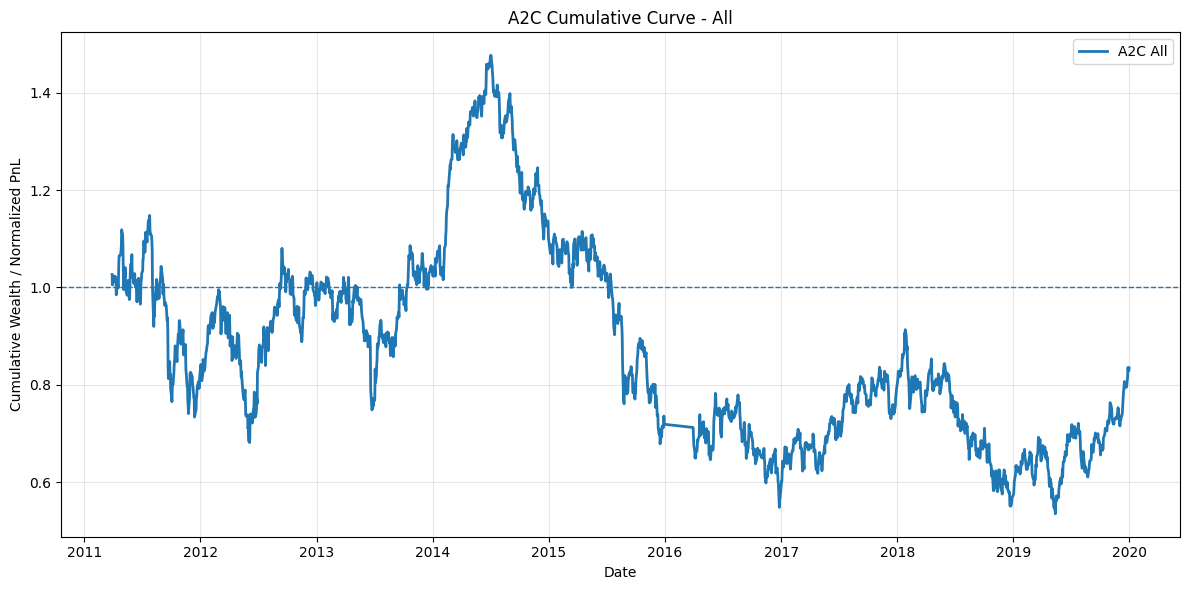

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd



a2c_results = build__by_asset(pnl_a2c_by_ticker, ticker_to_asset)
dates, curve = a2c_results["All"]
a2c_curve = pd.Series(curve, index=pd.to_datetime(dates))

plt.figure(figsize=(12, 6))
plt.plot(a2c_curve.index, a2c_curve.values, linewidth=2, label="A2C All")

plt.axhline(1.0, linestyle="--", linewidth=1)
plt.title("A2C Cumulative Curve - All")
plt.xlabel("Date")
plt.ylabel("Cumulative Wealth / Normalized PnL")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

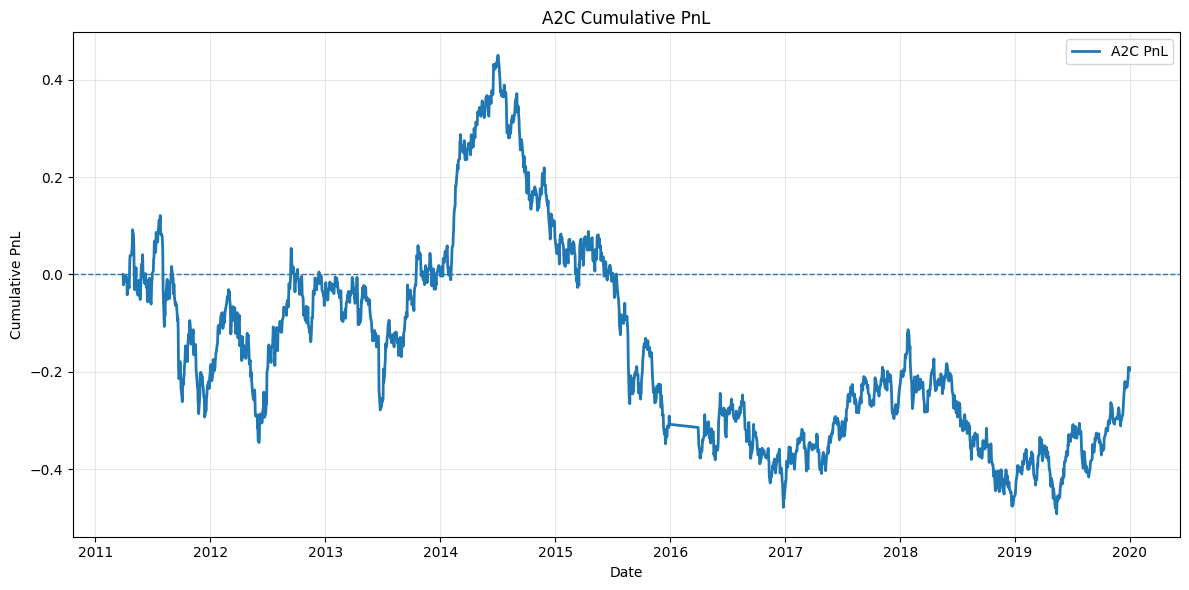

In [ ]:
cum_pnl = a2c_curve - a2c_curve.iloc[0]
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(cum_pnl.index, cum_pnl.values, linewidth=2, label="A2C PnL")

plt.axhline(0, linestyle="--", linewidth=1)
plt.title("A2C Cumulative PnL")
plt.xlabel("Date")
plt.ylabel("Cumulative PnL")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [ ]:
import pandas as pd
import numpy as np
import loaddata as ld

FEATURE_COLS = [
    "close_norm",
    "ret_1m", "ret_2m", "ret_3m", "ret_1y",
    "macd_8_24", "macd_16_48", "macd_32_96",
    "rsi_30",
]

WINDOW = 60

def diagnose_feature_cleaning(root_path, start=None, end=None):
    data_dict, panel, missing_files = ld.load_paper_rad_data(
        root_path=root_path,
        start=start,
        end=end
    )

    feature_dict, feature_panel = ld.build_paper_features(
        data_dict,
        dropna=False
    )

    rows = []

    for ticker in ld.PAPER_50:
        if ticker in missing_files:
            rows.append({
                "ticker": ticker,
                "stage": "load_paper_rad_data",
                "raw_rows": 0,
                "feature_rows": 0,
                "complete_feature_rows": 0,
                "state_rows": 0,
                "reason": "missing RAD file"
            })
            continue

        raw_df = data_dict[ticker]
        feat_df = feature_dict[ticker]

        available_feature_cols = [c for c in FEATURE_COLS if c in feat_df.columns]
        missing_feature_cols = [c for c in FEATURE_COLS if c not in feat_df.columns]

        if missing_feature_cols:
            rows.append({
                "ticker": ticker,
                "stage": "build_paper_features",
                "raw_rows": len(raw_df),
                "feature_rows": len(feat_df),
                "complete_feature_rows": 0,
                "state_rows": 0,
                "reason": f"missing feature columns: {missing_feature_cols}"
            })
            continue

        complete_mask = feat_df[FEATURE_COLS].notna().all(axis=1)
        complete_rows = int(complete_mask.sum())

        # make_state_tensor_single 会先 dropna(feature_cols)，然后要求至少 window+1 行
        state_rows = max(0, complete_rows - WINDOW)

        if state_rows <= 0:
            # 找最主要的 NaN 来源
            nan_counts = feat_df[FEATURE_COLS].isna().sum().sort_values(ascending=False)
            top_nan = nan_counts[nan_counts > 0].head(5).to_dict()

            if complete_rows == 0:
                reason = f"no rows with all required features; top NaN cols={top_nan}"
                stage = "make_state_tensor_single/dropna"
            else:
                reason = f"only {complete_rows} complete rows after feature dropna, need > {WINDOW}"
                stage = "make_state_tensor_single/window"

            rows.append({
                "ticker": ticker,
                "stage": stage,
                "raw_rows": len(raw_df),
                "feature_rows": len(feat_df),
                "complete_feature_rows": complete_rows,
                "state_rows": state_rows,
                "reason": reason
            })
            continue

        # 再检查 build_envs_from_state_dict 的 close/ret_1d/ewm_vol_60 要求
        X, dates, aligned_df = ld.make_state_tensor_single(
            feat_df,
            feature_cols=FEATURE_COLS,
            window=WINDOW,
            return_dates=True,
            return_current_row=True
        )

        usable = aligned_df[["close", "ret_1d", "ewm_vol_60"]].notna().all(axis=1)
        usable_rows = int(usable.sum())

        if usable_rows <= 2:
            rows.append({
                "ticker": ticker,
                "stage": "build_envs_from_state_dict",
                "raw_rows": len(raw_df),
                "feature_rows": len(feat_df),
                "complete_feature_rows": complete_rows,
                "state_rows": len(X),
                "reason": f"only {usable_rows} usable rows after close/ret_1d/ewm_vol_60 filter"
            })

    diag = pd.DataFrame(rows)

    if diag.empty:
        print("No contracts were removed under this diagnostic.")
    else:
        print("Removed contracts:")
        display(diag)

    return diag, data_dict, feature_dict


diag, data_dict, feature_dict = diagnose_feature_cleaning(
    root_path=DATA_ROOT,
    start="2005-01-01",
    end="2019-12-31"
)

Removed contracts:


,ticker,stage,raw_rows,feature_rows,complete_feature_rows,state_rows,reason
0,ZH,make_state_tensor_single/dropna,3777,3777,0,0,no rows with all required features; top NaN co...
1,ZU,make_state_tensor_single/dropna,3775,3775,0,0,no rows with all required features; top NaN co...
2,US,make_state_tensor_single/dropna,3778,3778,0,0,no rows with all required features; top NaN co...


In [ ]:
diag['reason'][0]

"no rows with all required features; top NaN cols={'close_norm': 3777, 'ret_1m': 3777, 'ret_2m': 3777, 'ret_3m': 3777, 'ret_1y': 3777}"